In [36]:
#1
import os
import librosa 
import librosa.display
import numpy as np 
import matplotlib.pyplot as plt 

%matplotlib inline

In [37]:
#2
DATA_DIR = r"D:\codeAlpha_tasks\Task3\data\archive\audio_speech_actors_01-24"

actors = sorted(os.listdir(DATA_DIR))

print(f"Number of actor Folders: {len(actors)}")
print(actors[:5])

Number of actor Folders: 24
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [38]:
#3
sample_actor= os.path.join(DATA_DIR,"Actor_01")
sample_files = os.listdir(sample_actor)
print(f"files in Actor_01: {len(sample_files)}")
print(sample_files[:3])

sample_path = os.path.join(sample_actor,sample_files[0])
y,sr = librosa.load(sample_path,sr = None)
print(f"Sample rate : {sr}, Duration:{len(y)/sr:.2f}sec, Shape: {y.shape}")

files in Actor_01: 60
['03-01-01-01-01-01-01.wav', '03-01-01-01-01-02-01.wav', '03-01-01-01-02-01-01.wav']
Sample rate : 48000, Duration:3.30sec, Shape: (158558,)


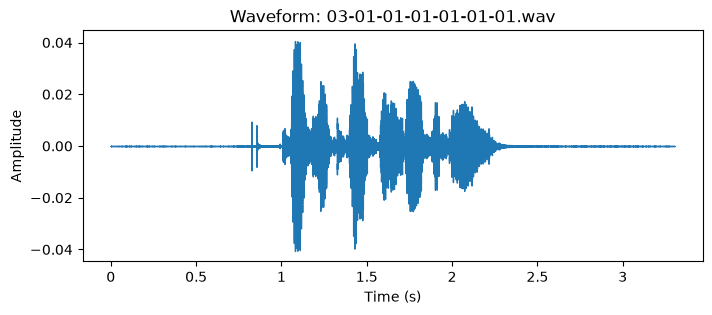

In [39]:
#4
plt.figure(figsize=(8,3))
librosa.display.waveshow(y,sr=sr)
plt.title(f"Waveform: {sample_files[0]}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


MFCC shape: (13, 310)


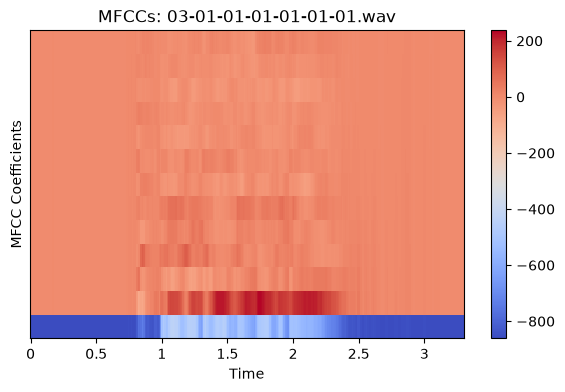

In [40]:
#5
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCC shape: {mfccs.shape}")

plt.figure(figsize=(7, 4))
librosa.display.specshow( mfccs,x_axis='time', sr=sr)
plt.colorbar()
plt.title(f"MFCCs: { sample_files[0]}")
plt.ylabel("MFCC Coefficients")
plt.show()

In [41]:
#6
MAX_LEN = 380
N_MFCC = 13

def extract_features(file_path,max_len = MAX_LEN , n_mfcc = N_MFCC):
    y,sr = librosa.load(file_path,sr = None)
    mfccs = librosa.feature.mfcc(y=y, sr= sr,n_mfcc= n_mfcc)
    
    if mfccs.shape[1] <max_len:
        pad_width =max_len - mfccs.shape[1]
        mfccs = np.pad(mfccs,pad_width=((0,0),(0,pad_width)),mode='constant')    
    else:
        mfccs = mfccs[:, :max_len]
        
    return mfccs

In [42]:
#7
sample_lengths = []
for actor in actors[:3]:
    actor_path = os.path.join(DATA_DIR, actor)
    for file in os.listdir(actor_path):
        y,sr = librosa.load(os.path.join(actor_path,file),sr = None )
        mfccs =librosa.feature.mfcc(y=y,sr = sr , n_mfcc=13)
        sample_lengths.append(mfccs.shape[1])
        
print(f"Min: {min(sample_lengths)}, Max: {max(sample_lengths)}, Avg: {np.mean(sample_lengths):.1f}")

Min: 298, Max: 470, Avg: 353.4


In [43]:
#8
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

X = []
y_labels = []

for actor in actors:
    actor_path = os.path.join(DATA_DIR, actor)
    for file in os.listdir(actor_path):
        file_path = os.path.join(actor_path, file)
        
        emotion_code = file.split('-')[2]
        emotion = emotion_map[emotion_code]
        
        features = extract_features(file_path)
        
        X.append(features)
        y_labels.append(emotion)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"X shape: {X.shape}")
print(f"y_labels shape: {y_labels.shape}")

X shape: (1440, 13, 380)
y_labels shape: (1440,)


In [44]:
#9
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

print(f"Classes : {le.classes_}")
print(f"Encoded example: {y_labels[0]} -> {y_encoded[0]}")

y_categorical = to_categorical(y_encoded)
print(f"y_categorical shape: {y_categorical.shape}")

Classes : ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Encoded example: neutral -> 5
y_categorical shape: (1440, 8)


In [45]:
#10
actor_ids = []
for actor in actors:
    actor_path= os.path.join(DATA_DIR,actor)
    for file in os.listdir(actor_path):
        actor_num = int(actor.split('_')[1])
        actor_ids.append(actor_num)
        
actor_ids= np.array (actor_ids)

train_mask = actor_ids <=20
test_mask = actor_ids > 20

X_train ,X_test = X[train_mask],X[test_mask]
y_train, y_test = y_categorical[train_mask], y_categorical[test_mask]

print(f"X_train: {X_train.shape} , X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} , y_test: {y_test.shape}")


X_train: (1200, 13, 380) , X_test: (240, 13, 380)
y_train: (1200, 8) , y_test: (240, 8)


In [46]:
#11
X_train = X_train[..., np.newaxis]
X_test= X_test[..., np.newaxis]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

mean = np.mean(X_train, axis=(0, 2, 3), keepdims=True)
std = np.std(X_train, axis=(0, 2, 3), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_test = (X_test - mean) / (std + 1e-8)

print(f"X_train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")



X_train shape: (1200, 13, 380, 1)
X_test shape: (240, 13, 380, 1)
X_train mean: 0.0000, std: 1.0000


In [47]:
#12
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(13, 380, 1), padding='same'),
    BatchNormalization(),
    MaxPooling2D((1, 4)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((1, 4)),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((1, 4)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

d:\codeAlpha_tasks\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 13, 380, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 13, 380, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 95, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 95, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 13, 95, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 13, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 13, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8320)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     1,065,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,159,688 (4.42 MB)

 Trainable params: 1,159,240 (4.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [48]:
#13
model.compile(
    optimizer = 'adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
#14
from sklearn.utils.class_weight import compute_class_weight

# Compute weights based on the training set's class distribution
y_train_labels = np.argmax(y_train, axis=1)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights_array))

print("Class weights:")
for idx, weight in class_weights.items():
    print(f"  {le.classes_[idx]}: {weight:.3f}")

Class weights:
  angry: 0.938
  calm: 0.938
  disgust: 0.938
  fearful: 0.938
  happy: 0.938
  neutral: 1.875
  sad: 0.938
  surprised: 0.938


In [50]:
model_weighted = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(13, 380, 1), padding='same'),
    BatchNormalization(),
    MaxPooling2D((1, 4)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((1, 4)),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((1, 4)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')
])

model_weighted.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_w = ModelCheckpoint(
    '../models/emotion_cnn_weighted.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_w = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_weighted = model_weighted.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint_w, early_stop_w],
    verbose=1
)

Epoch 1/50


d:\codeAlpha_tasks\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.2242 - loss: 3.0155
Epoch 1: val_accuracy improved from None to 0.25000, saving model to ../models/emotion_cnn_weighted.h5



Epoch 1: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.2242 - loss: 3.0155 - val_accuracy: 0.2500 - val_loss: 2.0518
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.2550 - loss: 1.9022
Epoch 2: val_accuracy did not improve from 0.25000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.2550 - loss: 1.9022 - val_accuracy: 0.1292 - val_loss: 3.6142
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.2925 - loss: 1.8410
Epoch 3: val_accuracy did not improve from 0.25000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.2925 - loss: 1.8410 - val_accuracy: 0.1333 - val_loss: 3.9412
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.3367 - loss: 1.7472
Epoch 4: val_accuracy did not improve from 0.25000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.3367 - loss: 1.7472 - val_accuracy: 0.1875 - val_loss: 2.6306
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


Epoch 5: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - accuracy: 0.3650 - loss: 1.7150 - val_accuracy: 0.3167 - val_loss: 1.9349
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.3817 - loss: 1.6186
Epoch 6: val_accuracy improved from 0.31667 to 0.33750, saving model to ../models/emotion_cnn_weighted.h5


...


Epoch 18: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.5267 - loss: 1.2006 - val_accuracy: 0.4625 - val_loss: 1.4105
Epoch 19/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5300 - loss: 1.1851
Epoch 19: val_accuracy improved from 0.46250 to 0.48333, saving model to ../models/emotion_cnn_weighted.h5



Epoch 19: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.5300 - loss: 1.1851 - val_accuracy: 0.4833 - val_loss: 1.4210
Epoch 20/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5425 - loss: 1.1841
Epoch 20: val_accuracy improved from 0.48333 to 0.50833, saving model to ../models/emotion_cnn_weighted.h5



Epoch 20: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.5425 - loss: 1.1841 - val_accuracy: 0.5083 - val_loss: 1.4489
Epoch 21/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5508 - loss: 1.1041
Epoch 21: val_accuracy did not improve from 0.50833
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.5508 - loss: 1.1041 - val_accuracy: 0.3958 - val_loss: 1.6377
Epoch 22/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5808 - loss: 1.0629
Epoch 22: val_accuracy improved from 0.50833 to 0.51667, saving model to ../models/emotion_cnn_weighted.h5



Epoch 22: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.5808 - loss: 1.0629 - val_accuracy: 0.5167 - val_loss: 1.5733
Epoch 23/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5817 - loss: 1.0456
Epoch 23: val_accuracy did not improve from 0.51667
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.5817 - loss: 1.0456 - val_accuracy: 0.4417 - val_loss: 1.5395
Epoch 24/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5958 - loss: 1.0336
Epoch 24: val_accuracy did not improve from 0.51667
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.5958 - loss: 1.0336 - val_accuracy: 0.4708 - val_loss: 1.4899
Epoch 25/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6267 - loss: 0.9687
Epoch 25: val_accuracy did not improve from 0.51667
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.6267 - loss: 0.9687 - val_accuracy: 0.4708 - val_loss: 1.4042
Epoch 26/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 172


Epoch 28: finished saving model to ../models/emotion_cnn_weighted.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 179ms/step - accuracy: 0.5833 - loss: 1.0020 - val_accuracy: 0.5417 - val_loss: 1.4881
Epoch 29/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6283 - loss: 0.9295
Epoch 29: val_accuracy did not improve from 0.54167
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.6283 - loss: 0.9295 - val_accuracy: 0.4500 - val_loss: 1.9240
Epoch 30/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6292 - loss: 0.9184
Epoch 30: val_accuracy did not improve from 0.54167
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.6292 - loss: 0.9184 - val_accuracy: 0.4458 - val_loss: 1.8201
Epoch 31/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6525 - loss: 0.8752
Epoch 31: val_accuracy did not improve from 0.54167
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.6525 - loss: 0.8752 - val_accuracy: 0.4708 - val_loss: 1.7706
Epoch 32/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 165

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
              precision    recall  f1-score   support

       angry       0.61      0.59      0.60        32
        calm       0.78      0.66      0.71        32
     disgust       0.44      0.84      0.58        32
     fearful       0.33      0.44      0.38        32
       happy       0.33      0.12      0.18        32
     neutral       0.40      0.75      0.52        16
         sad       0.36      0.16      0.22        32
   surprised       0.48      0.34      0.40        32

    accuracy                           0.47       240
   macro avg       0.47      0.49      0.45       240
weighted avg       0.47      0.47      0.44       240



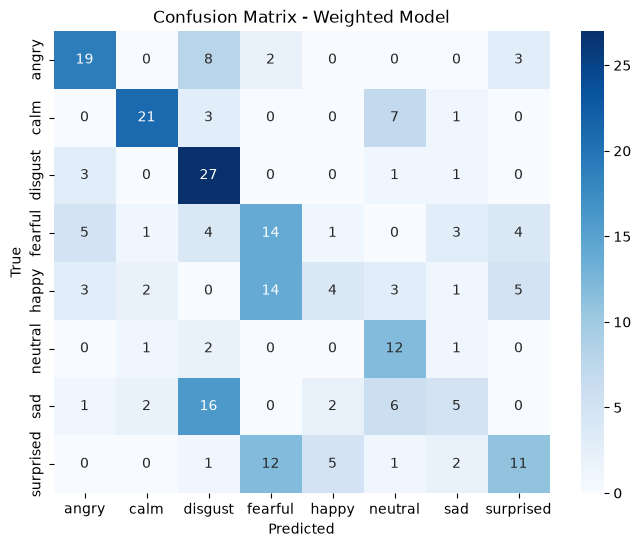

In [51]:
y_pred_probs_w = model_weighted.predict(X_test)
y_pred_w = np.argmax(y_pred_probs_w, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_w, target_names=le.classes_))

cm_w = confusion_matrix(y_true, y_pred_w)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Weighted Model')
plt.show()